Jan_24_Ensemble learning cancer surgery survival analysis prediction significance

In [1]:
"""Analysis ,significance & Prediction Surgery survival
"""

'Analysis ,significance & Prediction Surgery survival\n'

In [2]:
# import the basic library
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#For plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")





In [3]:
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Jan_24_Ensemble_learning\\Ensemble learning'

In [4]:
df=pd.read_csv("Surgery_survival.csv")

In [5]:
df.head()

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [6]:
# FIRST STEP is to understand the Problem Statements, Different Independents and Dependent Variable.

In [7]:
#### The dataset used in this article is the dataset. There are 4 columns in the dataset, 
"""which are described below.
Relevant Information:
The dataset contains cases from a study that was conducted between
1958 and 1970 at the University of Chicago's Billings Hospital on
the survival of patients who had undergone surgery for breast
cancer.
1.	Number of Instances: 306
2.	Number of Attributes: 4 (including the class attribute)

	Attribute Information:
1.	Age of patient at time of operation (numerical)
2.	Patient's year of operation (year - 1900, numerical)
3.	Number of positive axillary nodes detected (numerical)
4.	Survival status (class attribute)

1 = the patient survived 5 years or longer
2= the patient died within 5 year"""


"which are described below.\nRelevant Information:\nThe dataset contains cases from a study that was conducted between\n1958 and 1970 at the University of Chicago's Billings Hospital on\nthe survival of patients who had undergone surgery for breast\ncancer.\n1.\tNumber of Instances: 306\n2.\tNumber of Attributes: 4 (including the class attribute)\n\n\tAttribute Information:\n1.\tAge of patient at time of operation (numerical)\n2.\tPatient's year of operation (year - 1900, numerical)\n3.\tNumber of positive axillary nodes detected (numerical)\n4.\tSurvival status (class attribute)\n\n1 = the patient survived 5 years or longer\n2= the patient died within 5 year"

In [8]:
# changing the name of the columns for better understanding

In [9]:
df.rename(columns={"30":"age","64":"year","1":"nodes","1.1":"status"},inplace=True)

In [10]:
df.head()

,age,year,nodes,status
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [11]:
df.tail()

,age,year,nodes,status
300,75,62,1,1
301,76,67,0,1
302,77,65,3,1
303,78,65,1,2
304,83,58,2,2


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     305 non-null    int64
 1   year    305 non-null    int64
 2   nodes   305 non-null    int64
 3   status  305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [13]:
# ALL THE DATATYPES ARE integer .

In [14]:
# Basic Information about datapoint and features .

In [15]:
df.describe()

,age,year,nodes,status
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [16]:
df.nunique()

age       49
year      12
nodes     31
status     2
dtype: int64

In [17]:
df["status"].value_counts()

1    224
2     81
Name: status, dtype: int64

# advance EDA package

In [18]:
#The pandas profiling library can create, in a few lines of code, a rich and interactive suite of exploratory
#data analysis (EDA) tables and visualizations.

In [19]:
#!pip install pandas-profiling

In [20]:
import pandas_profiling
pandas_profiling.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Split in Independent & Dependent Variable:

In [21]:
X=df.drop(["status"],axis=1)
y=df["status"]

In [22]:
#Importing some Packages

In [23]:
from sklearn.model_selection import train_test_split



In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("TRAINIG RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

    print("TESTING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

# Ensemble learning

In [27]:
# BAGGING

# Bagging and Pasting in Ensemble Learning

In [28]:
#Importing necessary libraries:

In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [30]:
bagging_clf1 = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=100,
    max_samples=40, bootstrap=True,n_jobs=-1,random_state=101)

In [31]:
"""Let’s break down the code a little bit here, the above code will train 
an ensemble of 250 decision tree ,classifiers(n_estimators), 
and each of them is trained on 100 random subsets of the training data(max_samples)
with replacement as we are working on a bagging classifier 
but if you wish to work on pasting instead,go ahead and set the bootstrap = False. 
Lastly, the n_jobs parameters specify how many CPU cores you want to use 
for training and prediction(-1 means it can use all available). 
For regression, you can use BaggingRegressors."""

'Let’s break down the code a little bit here, the above code will train \nan ensemble of 250 decision tree ,classifiers(n_estimators), \nand each of them is trained on 100 random subsets of the training data(max_samples)\nwith replacement as we are working on a bagging classifier \nbut if you wish to work on pasting instead,go ahead and set the bootstrap = False. \nLastly, the n_jobs parameters specify how many CPU cores you want to use \nfor training and prediction(-1 means it can use all available). \nFor regression, you can use BaggingRegressors.'

# Out-Of-Bag Evaluation

In [32]:
""" Whenever use bagging, there is some amount of data that might be sampled(selecting subset) 
more than once, or perhaps even more and there might be some data that is not sampled at all. 
Bagging Classifier samples n training instances with replacement by default, which means only around 63% of data is 
sampled on an average for each predictor. The rest of the 37% of the data are not sampled at all, 
now these data/instances are knowns as out-of-bag(OOB) instances. 

Since our model never saw this data before, it can be useful for evaluating removing the need for separate validation data.

Bagging classifier has a parameter oob_score which upon setting true will automatically use oobs for evaluation 
after training is done.  """

' Whenever use bagging, there is some amount of data that might be sampled(selecting subset) \nmore than once, or perhaps even more and there might be some data that is not sampled at all. \nBagging Classifier samples n training instances with replacement by default, which means only around 63% of data is \nsampled on an average for each predictor. The rest of the 37% of the data are not sampled at all, \nnow these data/instances are knowns as out-of-bag(OOB) instances. \n\nSince our model never saw this data before, it can be useful for evaluating removing the need for separate validation data.\n\nBagging classifier has a parameter oob_score which upon setting true will automatically use oobs for evaluation \nafter training is done.  '

In [33]:
bagging_clf1.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=40,
                  n_estimators=100, n_jobs=-1, random_state=101)

In [34]:
y_pred = bagging_clf1.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7532467532467533


In [35]:
scores = {
    'Bagging Classifier': {
        'Train': accuracy_score(y_train, bagging_clf1.predict(X_train)),
        'Test': accuracy_score(y_test, bagging_clf1.predict(X_test)),
    },
}

In [36]:
print(scores["Bagging Classifier"])

{'Train': 0.7894736842105263, 'Test': 0.7532467532467533}


In [37]:
evaluate(bagging_clf1, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[158  11]
 [ 37  22]]
ACCURACY SCORE:
0.7895
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.810256   0.666667  0.789474    0.738462      0.773099
recall       0.934911   0.372881  0.789474    0.653896      0.789474
f1-score     0.868132   0.478261  0.789474    0.673196      0.767244
support    169.000000  59.000000  0.789474  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[50  5]
 [14  8]]
ACCURACY SCORE:
0.7532
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.781250   0.615385  0.753247   0.698317      0.733860
recall      0.909091   0.363636  0.753247   0.636364      0.753247
f1-score    0.840336   0.457143  0.753247   0.648739      0.730852
support    55.000000  22.000000  0.753247  77.000000     77.000000


# OUT_OF_BAG TRUE

In [38]:
bagging_clf2 = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=100,max_samples=40,
    bootstrap=True, oob_score=True, random_state=101)

In [39]:
bagging_clf2.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=40,
                  n_estimators=100, oob_score=True, random_state=101)

In [40]:
bagging_clf2.oob_score_

0.7236842105263158

In [41]:
evaluate(bagging_clf2, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[158  11]
 [ 37  22]]
ACCURACY SCORE:
0.7895
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.810256   0.666667  0.789474    0.738462      0.773099
recall       0.934911   0.372881  0.789474    0.653896      0.789474
f1-score     0.868132   0.478261  0.789474    0.673196      0.767244
support    169.000000  59.000000  0.789474  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[50  5]
 [14  8]]
ACCURACY SCORE:
0.7532
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.781250   0.615385  0.753247   0.698317      0.733860
recall      0.909091   0.363636  0.753247   0.636364      0.753247
f1-score    0.840336   0.457143  0.753247   0.648739      0.730852
support    55.000000  22.000000  0.753247  77.000000     77.000000


# Random Forests

In [42]:
"""  the Random forest is just an ensemble of decision trees trained by the bagging method. 
Here, the max_Samples are set to the size of training data. So instead of creating a bagging 
classifier using decision trees, it is better to straight away use the RandomForest Classifier or 
RandomForest Regressor(for regression) which is way more optimized and efficient to use.  """

'  the Random forest is just an ensemble of decision trees trained by the bagging method. \nHere, the max_Samples are set to the size of training data. So instead of creating a bagging classifier \nusing decision trees, it is better for you to straight away use the RandomForest Classifier or \nRandomForest Regressor(for regression) which is way more optimized and efficient to use.  '

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
random_forest_clf = RandomForestClassifier(n_estimators=80, max_leaf_nodes=16, random_state=42,n_jobs=-1)
random_forest_clf.fit(X_train, y_train)

RandomForestClassifier(max_leaf_nodes=16, n_estimators=80, n_jobs=-1,
                       random_state=42)

In [45]:
""" The above code trains a Random Forest Classifier with 500 trees(n_estimators=500) and uses all available CPU cores, 
as we have specified n_jobs =-1, each of them limited to a maximum of 16 nodes. """

' The above code trains a Random Forest Classifier with 500 trees(n_estimators=500) and uses all available CPU cores, \nas we have specified n_jobs =-1, each of them limited to a maximum of 16 nodes. '

In [46]:
y_pred_random_forest = random_forest_clf.predict(X_test)

In [47]:
""" Random Forest Classifier consists of all the hyperparameters of a Decision Tree Classifier as well as that of
Bagging Classifier to control the process.

The Random Forest algorithm uses extra randomness when growing trees. Instead of searching for the best feature 
while splitting the node. What it does is, searches for the best feature among a random subset of features. 
The algorithm also trades a higher bias for a lower variance, in turn increasing the overall accuracy.  """

' Random Forest Classifier consists of all the hyperparameters of a Decision Tree Classifier as well as that of\nBagging Classifier to control the process.\n\nThe Random Forest algorithm uses extra randomness when growing trees. Instead of searching for the best feature \nwhile splitting the node. What it does is, searches for the best feature among a random subset of features. \nThe algorithm also trades a higher bias for a lower variance, in turn increasing the overall accuracy.  '

In [48]:
print(accuracy_score(y_test, y_pred_random_forest))

0.7532467532467533


In [49]:
scores['Random Forest'] = {
        'Train': accuracy_score(y_train, random_forest_clf.predict(X_train)),
        'Test': accuracy_score(y_test, random_forest_clf.predict(X_test)),
    }

In [50]:
print(scores["Random Forest"])

{'Train': 0.8377192982456141, 'Test': 0.7532467532467533}


In [51]:
evaluate(random_forest_clf, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[166   3]
 [ 34  25]]
ACCURACY SCORE:
0.8377
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.830000   0.892857  0.837719    0.861429      0.846266
recall       0.982249   0.423729  0.837719    0.702989      0.837719
f1-score     0.899729   0.574713  0.837719    0.737221      0.815624
support    169.000000  59.000000  0.837719  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[50  5]
 [14  8]]
ACCURACY SCORE:
0.7532
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.781250   0.615385  0.753247   0.698317      0.733860
recall      0.909091   0.363636  0.753247   0.636364      0.753247
f1-score    0.840336   0.457143  0.753247   0.648739      0.730852
support    55.000000  22.000000  0.753247  77.000000     77.000000


In [52]:
# same approach as Random forest

In [53]:
bagging_clf = BaggingClassifier(
    DecisionTreeClassifier(max_leaf_nodes=16),
    n_estimators=500, random_state=101)

In [54]:
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)

In [55]:
print(accuracy_score(y_test, y_pred_bagging))

0.7272727272727273


# EXTRA TREE CLASSIFIER

In [56]:
from sklearn.ensemble import ExtraTreesClassifier


#ex_tree_clf = ExtraTreesClassifier(random_state=42)
#ex_tree_clf.fit(X_train, y_train)

In [57]:
#ex_tree_clf = ExtraTreesClassifier(random_state=42)
ex_tree_clf = ExtraTreesClassifier(max_features= "log2", random_state=42,n_estimators=100)
#ex_tree_clf = ExtraTreesClassifier(n_estimators=500, max_features=7, random_state=42)

In [58]:
ex_tree_clf

ExtraTreesClassifier(max_features='log2', random_state=42)

In [59]:
ex_tree_clf.fit(X_train, y_train)
y_pred_ETF = ex_tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_ETF))

0.7012987012987013


In [60]:
evaluate(ex_tree_clf, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[169   0]
 [  2  57]]
ACCURACY SCORE:
0.9912
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.988304   1.000000  0.991228    0.994152      0.991331
recall       1.000000   0.966102  0.991228    0.983051      0.991228
f1-score     0.994118   0.982759  0.991228    0.988438      0.991178
support    169.000000  59.000000  0.991228  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[45 10]
 [13  9]]
ACCURACY SCORE:
0.7013
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.775862   0.473684  0.701299   0.624773      0.689526
recall      0.818182   0.409091  0.701299   0.613636      0.701299
f1-score    0.796460   0.439024  0.701299   0.617742      0.694336
support    55.000000  22.000000  0.701299  77.000000     77.000000


In [61]:
scores['EXTRA TREE CLASSIFIER'] = {
        'Train': accuracy_score(y_train, ex_tree_clf.predict(X_train)),
        'Test': accuracy_score(y_test, ex_tree_clf.predict(X_test)),
    }

In [62]:
print(scores["EXTRA TREE CLASSIFIER"])

{'Train': 0.9912280701754386, 'Test': 0.7012987012987013}


In [63]:
#SAMPLE CODE FOR BAGGING REGRESSOR

In [64]:
"""from sklearn.ensemble import BaggingRegressor
model = BaggingRegressor(tree.DecisionTreeRegressor(random_state=1))
model.fit(x_train, y_train)
model.score(x_test,y_test)"""

'from sklearn.ensemble import BaggingRegressor\nmodel = BaggingRegressor(tree.DecisionTreeRegressor(random_state=1))\nmodel.fit(x_train, y_train)\nmodel.score(x_test,y_test)'

# voting

In [65]:
#Initializing the models:

In [66]:
log = LogisticRegression()

rnd = RandomForestClassifier(n_estimators=100)

svm = SVC()

from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5) 

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()



In [67]:
voting = VotingClassifier(
    estimators=[('logistics_regression', log), ('random_forest', rnd), ('support_vector_machine', svm),("KNN_Classifier",knn),("Gaussian NB",gnb)],
    voting='hard')

In [68]:
#Here we are setting voting = ‘hard’ means it will be following majority rule voting and n_estimators as 100. 
#The rest of all the parameters are by default.

In [69]:
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('logistics_regression', LogisticRegression()),
                             ('random_forest', RandomForestClassifier()),
                             ('support_vector_machine', SVC()),
                             ('KNN_Classifier', KNeighborsClassifier()),
                             ('Gaussian NB', GaussianNB())])

In [70]:
for clf in (log, rnd, svm, knn,gnb, voting):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.7272727272727273
RandomForestClassifier 0.7012987012987013
SVC 0.7142857142857143
KNeighborsClassifier 0.7922077922077922
GaussianNB 0.7402597402597403
VotingClassifier 0.7532467532467533


In [71]:
scores['Voting'] = {
        'Train': accuracy_score(y_train, voting.predict(X_train)),
        'Test': accuracy_score(y_test, voting.predict(X_test)),
    }

In [72]:
print(scores["Voting"])

{'Train': 0.7719298245614035, 'Test': 0.7532467532467533}


In [73]:
evaluate(voting, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[164   5]
 [ 47  12]]
ACCURACY SCORE:
0.7719
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.777251   0.705882   0.77193    0.741567      0.758783
recall       0.970414   0.203390   0.77193    0.586902      0.771930
f1-score     0.863158   0.315789   0.77193    0.589474      0.721514
support    169.000000  59.000000   0.77193  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[52  3]
 [16  6]]
ACCURACY SCORE:
0.7532
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.764706   0.666667  0.753247   0.715686      0.736695
recall      0.945455   0.272727  0.753247   0.609091      0.753247
f1-score    0.845528   0.387097  0.753247   0.616313      0.714548
support    55.000000  22.000000  0.753247  77.000000     77.000000


# BOOSTING

# ADABOOST

In [74]:
"""AdaBoost
Adaptive boosting or AdaBoost boosting algorithms. 

Usually, decision trees are used for modelling. 

Multiple sequential models are created, each correcting the errors from the last model. AdaBoost assigns weights 
to the observations which are incorrectly predicted and the subsequent model works to predict these values correctly.

Below are the steps for performing the AdaBoost algorithm:

(1)Initially, all observations in the dataset are given equal weights.

(2)A model is built on the subset of data.
Using this model, predictions are made on the whole dataset.

(3)Errors are calculated by comparing the predictions and actual values.

(4)While creating the next model, higher weights are given to the data points which were predicted incorrectly.
Weights can be determined using the error value. For instance, higher the error more is the weight assigned to the observation.

(5)This process is repeated until the error function does not change, or the maximum limit of the number of 
estimators is reached."""

'AdaBoost\nAdaptive boosting or AdaBoost boosting algorithms. \n\nUsually, decision trees are used for modelling. \n\nMultiple sequential models are created, each correcting the errors from the last model. AdaBoost assigns weights \nto the observations which are incorrectly predicted and the subsequent model works to predict these values correctly.\n\nBelow are the steps for performing the AdaBoost algorithm:\n\n(1)Initially, all observations in the dataset are given equal weights.\n\n(2)A model is built on the subset of data.\nUsing this model, predictions are made on the whole dataset.\n\n(3)Errors are calculated by comparing the predictions and actual values.\n\n(4)While creating the next model, higher weights are given to the data points which were predicted incorrectly.\nWeights can be determined using the error value. For instance, higher the error more is the weight assigned to the observation.\n\n(5)This process is repeated until the error function does not change, or the maxim

In [75]:
from sklearn.ensemble import AdaBoostClassifier

In [76]:
adaboost_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME.R", learning_rate=0.5, random_state=42)
adaboost_clf.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200, random_state=42)

In [77]:
y_pred_adb = adaboost_clf.predict(X_test)
accuracy_score(y_test, y_pred_adb)

0.7272727272727273

In [78]:
scores['ADABOOST'] = {
        'Train': accuracy_score(y_train, adaboost_clf.predict(X_train)),
        'Test': accuracy_score(y_test, adaboost_clf.predict(X_test)),
    }

In [79]:
print(scores["ADABOOST"])

{'Train': 0.8026315789473685, 'Test': 0.7272727272727273}


In [80]:
evaluate(adaboost_clf, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[160   9]
 [ 36  23]]
ACCURACY SCORE:
0.8026
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.816327   0.718750  0.802632    0.767538      0.791076
recall       0.946746   0.389831  0.802632    0.668288      0.802632
f1-score     0.876712   0.505495  0.802632    0.691103      0.780652
support    169.000000  59.000000  0.802632  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[48  7]
 [14  8]]
ACCURACY SCORE:
0.7273
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.774194   0.533333  0.727273   0.653763      0.705376
recall      0.872727   0.363636  0.727273   0.618182      0.727273
f1-score    0.820513   0.432432  0.727273   0.626473      0.709633
support    55.000000  22.000000  0.727273  77.000000     77.000000


In [81]:
#SAMPLE ADABOOST CODE FOR REGRESSION APPLICATION

In [82]:
"""from sklearn.ensemble import AdaBoostRegressor
model = AdaBoostRegressor()
model.fit(x_train, y_train)
model.score(x_test,y_test)"""

'from sklearn.ensemble import AdaBoostRegressor\nmodel = AdaBoostRegressor()\nmodel.fit(x_train, y_train)\nmodel.score(x_test,y_test)'

#  GRADIENT BOOSTING

In [83]:
"""

Gradient Boosting (GBM)
Gradient Boosting or GBM is another ensemble machine learning algorithm that works for both regression and 
classification problems. 
GBM uses the boosting technique, combining a number of weak learners to form a strong learner. 
Regression trees used as a base learner, each subsequent tree in series is built on the errors calculated by the 
previous tree.

ADA BOOSTING:- Its focus on training the prior miscalculated observations and it alters the distribution of 
the dataset to enhance the weight on sample values which are hard  for classification

Just like AdaBoost, Gradient Boost also combines a no. of weak learners to form a strong learner. 
Here, the residual of the current classifier becomes the input for the next consecutive classifier on which 
the trees are built, and hence it is an additive model. The residuals are captured in a step-by-step manner 
by the classifiers, in order to capture the maximum variance within the data, this is done by introducing the 
learning rate to the classifiers.


"""

'\n\nGradient Boosting (GBM)\nGradient Boosting or GBM is another ensemble machine learning algorithm that works for both regression and \nclassification problems. \nGBM uses the boosting technique, combining a number of weak learners to form a strong learner. \nRegression trees used as a base learner, each subsequent tree in series is built on the errors calculated by the \nprevious tree.\n\nADA BOOSTING:- Its focus on training the prior miscalculated observations and it alters the distribution of \nthe dataset to enhance the weight on sample values which are hard  for classification\n\nJust like AdaBoost, Gradient Boost also combines a no. of weak learners to form a strong learner. \nHere, the residual of the current classifier becomes the input for the next consecutive classifier on which \nthe trees are built, and hence it is an additive model. The residuals are captured in a step-by-step manner \nby the classifiers, in order to capture the maximum variance within the data, this is

In [84]:
#Stochastic Gradient Boosting

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

In [86]:
gbrt = GradientBoostingClassifier(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
gbrt.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=2, n_estimators=3,
                           random_state=42)

In [87]:
y_pred_gd = gbrt.predict(X_test)
accuracy_score(y_test, y_pred_gd)

0.7532467532467533

In [88]:
scores['GradientBoost'] = {
        'Train': accuracy_score(y_train, gbrt.predict(X_train)),
        'Test': accuracy_score(y_test, gbrt.predict(X_test)),
    }

In [89]:
print(scores['GradientBoost'])

{'Train': 0.7894736842105263, 'Test': 0.7532467532467533}


In [90]:
evaluate(gbrt, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[160   9]
 [ 39  20]]
ACCURACY SCORE:
0.7895
CLASSIFICATION REPORT:
                    1          2  accuracy   macro avg  weighted avg
precision    0.804020   0.689655  0.789474    0.746838      0.774426
recall       0.946746   0.338983  0.789474    0.642864      0.789474
f1-score     0.869565   0.454545  0.789474    0.662055      0.762170
support    169.000000  59.000000  0.789474  228.000000    228.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[51  4]
 [15  7]]
ACCURACY SCORE:
0.7532
CLASSIFICATION REPORT:
                   1          2  accuracy  macro avg  weighted avg
precision   0.772727   0.636364  0.753247   0.704545      0.733766
recall      0.927273   0.318182  0.753247   0.622727      0.753247
f1-score    0.842975   0.424242  0.753247   0.633609      0.723337
support    55.000000  22.000000  0.753247  77.000000     77.000000


# XGBoost

In [91]:
""" XGBoost
XGBoost (extreme Gradient Boosting) is an advanced implementation of the gradient boosting algorithm. 
XGBoost has proved to be a highly effective ML algorithm. 
XGBoost has high predictive power and is almost 10 times faster than the other gradient boosting techniques. 
It also includes a variety of regularization which reduces overfitting and improves overall performance. 
Hence it is also known as ‘regularized boosting‘ technique.

Let us see how XGBoost is comparatively better than other techniques:

Regularization:
Standard GBM implementation has no regularisation like XGBoost.
Thus XGBoost also helps to reduce overfitting.
Parallel Processing:
XGBoost implements parallel processing and is faster than GBM .
XGBoost also supports implementation on Hadoop.(Hadoop is an open source framework from Apache and is used to 
store process and analyze data which are very huge in volume.
High Flexibility:
"""

' XGBoost\nXGBoost (extreme Gradient Boosting) is an advanced implementation of the gradient boosting algorithm. \nXGBoost has proved to be a highly effective ML algorithm. \nXGBoost has high predictive power and is almost 10 times faster than the other gradient boosting techniques. \nIt also includes a variety of regularization which reduces overfitting and improves overall performance. \nHence it is also known as ‘regularized boosting‘ technique.\n\nLet us see how XGBoost is comparatively better than other techniques:\n\nRegularization:\nStandard GBM implementation has no regularisation like XGBoost.\nThus XGBoost also helps to reduce overfitting.\nParallel Processing:\nXGBoost implements parallel processing and is faster than GBM .\nXGBoost also supports implementation on Hadoop.(Hadoop is an open source framework from Apache and is used to \nstore process and analyze data which are very huge in volume.\nHigh Flexibility:\n'

In [92]:
import xgboost as xgb
model_xgb=xgb.XGBClassifier(random_state=1,learning_rate=0.01)
model_xgb.fit(X_train, y_train)
Train_accuracy=model_xgb.score(X_train,y_train)
Test_accuracy=model_xgb.score(X_test,y_test)
print("Train accuracy",Train_accuracy)
print("Test accuracy",Test_accuracy)

Train accuracy 0.8070175438596491
Test accuracy 0.7272727272727273


In [93]:
scores['XGBOOST'] = {
        'Train': model_xgb.score(X_train,y_train),
        'Test': model_xgb.score(X_test,y_test),
    }

In [94]:
print(scores['XGBOOST'])

{'Train': 0.8070175438596491, 'Test': 0.7272727272727273}


In [95]:
#model_xgb.feature_importances_(model_xgb)

# lightgbm

In [96]:
""" Light GBM
Light GBM beats all the other algorithms when the dataset is extremely large. 
Compared to the other algorithms, Light GBM takes lesser time to run on a huge dataset.

LightGBM is a gradient boosting framework that uses tree-based algorithms and follows leaf-wise approach 
while other algorithms work in a level-wise approach pattern. The images below will help you understand the difference 
in a better way."""

' Light GBM\nLight GBM beats all the other algorithms when the dataset is extremely large. \nCompared to the other algorithms, Light GBM takes lesser time to run on a huge dataset.\n\nLightGBM is a gradient boosting framework that uses tree-based algorithms and follows leaf-wise approach \nwhile other algorithms work in a level-wise approach pattern. The images below will help you understand the difference \nin a better way.'

In [97]:
#!pip3 install lightgbm

In [98]:
import lightgbm as lgb
model = lgb.LGBMClassifier()
model.fit(X_train, y_train)
print(); print(model)

expected_y  = y_test
predicted_y = model.predict(X_test)


LGBMClassifier()


In [99]:
scores['LGB'] = {
        'Train': model.score(X_train,y_train),
        'Test': model.score(X_test,y_test),
    }

In [100]:
print(scores['LGB'])

{'Train': 0.8771929824561403, 'Test': 0.7012987012987013}


In [101]:
model1 = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
model1.fit(X_train,y_train,eval_set=[(X_test,y_test),(X_train,y_train)],
          verbose=20,eval_metric='logloss')

[20]	training's binary_logloss: 0.434406	valid_0's binary_logloss: 0.529408
[40]	training's binary_logloss: 0.386227	valid_0's binary_logloss: 0.529105
[60]	training's binary_logloss: 0.353132	valid_0's binary_logloss: 0.539419
[80]	training's binary_logloss: 0.327469	valid_0's binary_logloss: 0.55433
[100]	training's binary_logloss: 0.304162	valid_0's binary_logloss: 0.563913


LGBMClassifier(learning_rate=0.09, max_depth=-5, random_state=42)

In [102]:
print('Training accuracy {:.4f}'.format(model.score(X_train,y_train)))
print('Testing accuracy {:.4f}'.format(model.score(X_test,y_test)))

Training accuracy 0.8772
Testing accuracy 0.7013


<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

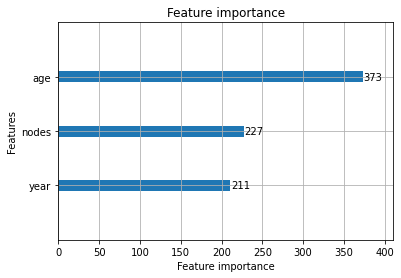

In [103]:
lgb.plot_importance(model)

# CONCLUSION

<AxesSubplot:>

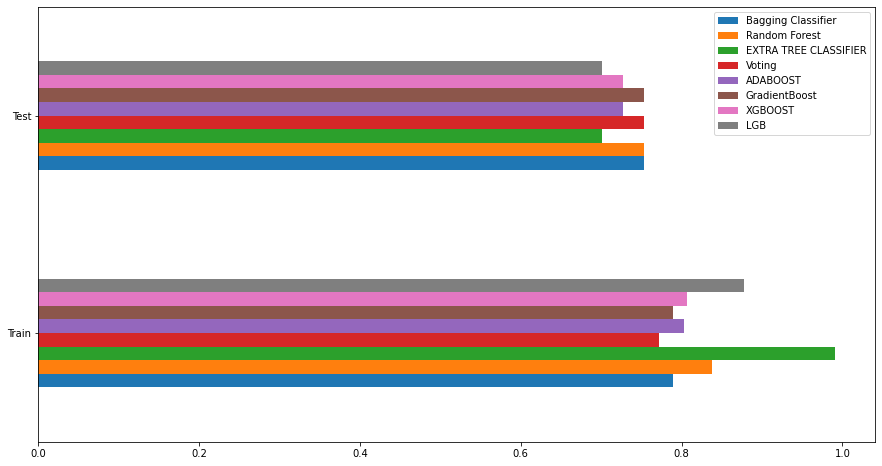

In [104]:
scores_df = pd.DataFrame(scores)

scores_df.plot(kind='barh', figsize=(15, 8))

In [105]:
#Remark:-

# STACKING

In [106]:
#from mlxtend.classifier import BlendingClassifier
from mlxtend.classifier import StackingClassifier

In [107]:
from sklearn import model_selection

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier



In [108]:

clf1=SVC()
clf2=RandomForestClassifier(n_estimators=30, random_state=42)
clf3=KNeighborsClassifier()
clf4 = LogisticRegression(random_state=42)

XGB = XGBClassifier(use_label_encoder=False,learning_rate=0.02, objective='binary:logistic',n_estimators=30, nthread=2,eval_metric='logloss')
#use_label_encoder=False


In [109]:
sclf=StackingClassifier(classifiers=[clf1,clf2,clf3,clf4],meta_classifier=XGB)

In [110]:
for sclf, label in zip([clf1,clf2,clf3,clf4,sclf],["SVC","RandomForest","KNN","LR","StackingClassifier"]):
    
    scores=model_selection.cross_val_score(sclf,X_train,y_train,cv=3,scoring="accuracy")
    print("************")
    print("3-fold cross validation:\n")
    #print(scores)
    print("accuracy of CV = 3  of  ",label,"  are  ",scores)
   
    #print("Accuracy: %0.2f(+/- %0.2f)[%s]"%(scores.mean(),scores.std(),label))
    #print("Accuracy: %0.2f(+/- %0.2f)[%s]"%("MEAN ACCURACY",scores.mean(),"STANDARD DEVIATION",scores.std(),"USING ALGORITHM",label))
    print("mean Accuracy and SD is: %0.2f(+/- %0.2f)[%s]"%(scores.mean(),scores.std(),label))

************
3-fold cross validation:

accuracy of CV = 3  of   SVC   are   [0.73684211 0.73684211 0.75      ]
mean Accuracy and SD is: 0.74(+/- 0.01)[SVC]
************
3-fold cross validation:

accuracy of CV = 3  of   RandomForest   are   [0.64473684 0.67105263 0.69736842]
mean Accuracy and SD is: 0.67(+/- 0.02)[RandomForest]
************
3-fold cross validation:

accuracy of CV = 3  of   KNN   are   [0.77631579 0.67105263 0.64473684]
mean Accuracy and SD is: 0.70(+/- 0.06)[KNN]
************
3-fold cross validation:

accuracy of CV = 3  of   LR   are   [0.73684211 0.73684211 0.76315789]
mean Accuracy and SD is: 0.75(+/- 0.01)[LR]
************
3-fold cross validation:

accuracy of CV = 3  of   StackingClassifier   are   [0.64473684 0.67105263 0.69736842]
mean Accuracy and SD is: 0.67(+/- 0.02)[StackingClassifier]


In [111]:
# mean accuracy of stacking classifier is improved

# CONCLUSION 